## 2) Interpolacion Polinomial y Lagrange

### Ejercicio 2.1 - Interpolacion polinomial simple
Datos de crecimiento (dias, mg):

| dia | 0 | 6 | 10 | 13 | 17 | 20 | 28 |
|---|---:|---:|---:|---:|---:|---:|---:|
| peso | 6.67 | 17.33 | 42.67 | 37.33 | 30.10 | 29.31 | 28.74 |

1. Construye `A = md.Matrix(dias)`.
2. Obtiene coeficientes con `sl.eliminacion_DD(A, peso)`.
3. Forma el polinomio y aproxima el peso en dia 4, 11 y 25.
4. Grafica datos vs polinomio.

### Ejercicio 2.2 - Lagrange y validacion
Con los datos
$$(0,1.00000),\;(0.6,1.264911),\;(0.9,1.378404)$$
haz:
1. `P_L(x)` con `md.lagrange`.
2. Aproxima `f(0.45)` y calcula error absoluto contra `1.204158`.
3. Repite usando `md.polinomial_simple` y compara resultados.

### Ejercicio 2.3 - Cero de un polinomio interpolante
Usa los datos:

| x | 0 | 0.5 | 1 | 1.5 | 2 | 2.5 | 3 |
|---|---:|---:|---:|---:|---:|---:|---:|
| y | 1.8421 | 2.4694 | 2.4921 | 1.9047 | 0.8509 | -0.4112 | -1.5727 |

1. Construye un polinomio con 3 nodos cercanos al cambio de signo.
2. Construye otro con 4 nodos cercanos.
3. Halla una aproximacion de la raiz con `cz.Newton(P, semilla, tol)` en ambos casos.
4. Compara estabilidad y sensibilidad de la raiz.


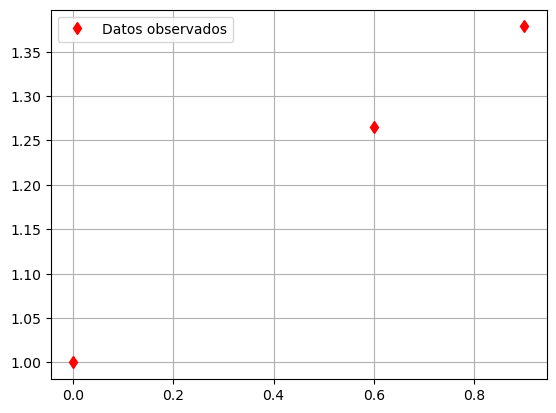

In [1]:
import sel as sel 
import modelos as md
import numpy as np
import matplotlib.pyplot as plt


x_data=np.array([0 , 0.6 , 0.9 ], float)
y_data=np.array([1.00000, 1.2649911, 1.378404], float)

x_values=np.linspace(min(x_data), max(x_data), 10)

plt.plot(x_data,y_data, 'rd', label='Datos observados')
plt.legend()
plt.grid()



In [2]:
P_L=md.lagrange(x_data, y_data)
print(P_L)

-0.0706764814814811*x**2 + 0.484057722222223*x + 1.0


In [3]:
import sympy as sp

x= sp.symbols('x')
P_value= sp.lambdify(x,P_L)

print(P_value(0.45))

error_abs= abs(1.204158-(P_value(0.45)))
print(f"El error absoluto es: {error_abs}")


1.2035139875000005
El error absoluto es: 0.0006440124999995689


In [4]:
P_PS=md.polinomial_simple(x_data,y_data)
print(P_PS)


-0.0706764814814818*x**2 + 0.484057722222222*x + 1.0


In [5]:
import sympy as sp

x= sp.symbols('x')
Ps_value= sp.lambdify(x,P_PS)

print(Ps_value(0.45))

error_abs= abs(1.204158-(Ps_value(0.45)))
print(f"El error absoluto es: {error_abs}")

1.2035139874999998
El error absoluto es: 0.000644012500000235



### Ejercicio 2.3 - Cero de un polinomio interpolante
Usa los datos:

| x | 0 | 0.5 | 1 | 1.5 | 2 | 2.5 | 3 |
|---|---:|---:|---:|---:|---:|---:|---:|
| y | 1.8421 | 2.4694 | 2.4921 | 1.9047 | 0.8509 | -0.4112 | -1.5727 |

1. Construye un polinomio con 3 nodos cercanos al cambio de signo.
2. Construye otro con 4 nodos cercanos.
3. Halla una aproximacion de la raiz con `cz.Newton(P, semilla, tol)` en ambos casos.
4. Compara estabilidad y sensibilidad de la raiz.


-0.9328*x**2 + 1.1572*x + 2.2677


2.298323178249583

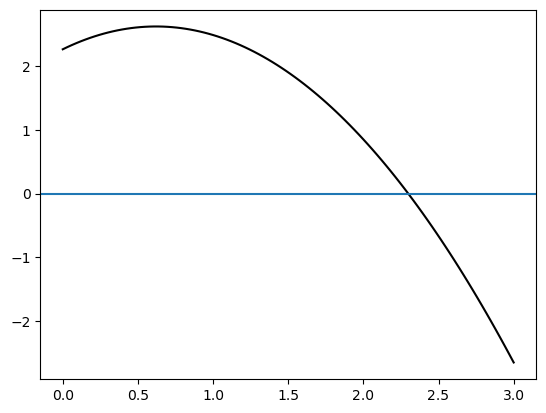

In [34]:

x_data=np.array([1, 1.5, 2], float)
y_data=np.array([2.4921, 1.9047, 0.8509], float)

P_pols=md.polinomial_simple(x_data, y_data)
print(P_pols)

P_pols_evalues=sp.lambdify(x,P_pols)
x_values=np.linspace(0, 3, 100)
plt.plot (x_values, P_pols_evalues(x_values), 'k')
plt.axhline(0)

import ceros as cr
cr.Newton(P_pols, 2.4, 1e-6)


0.191600000000001*x**3 - 1.795*x**2 + 2.4026*x + 1.6929


2.3193168941533013

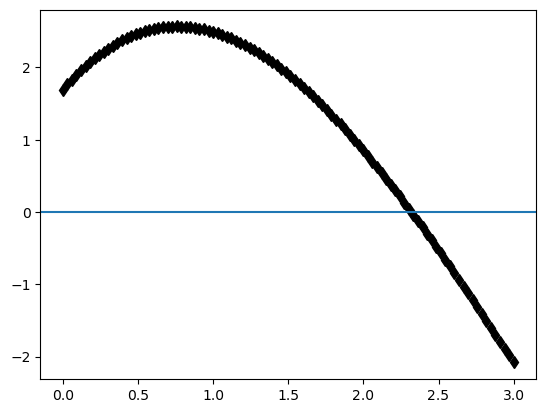

In [ ]:
x_data=np.array([0.5, 1, 1.5, 2], float)
y_data=np.array([2.4694, 2.4921, 1.9047, 0.8509], float)

P_pols=md.polinomial_simple(x_data, y_data)
print(P_pols)

P_pols_evalues=sp.lambdify(x,P_pols)
x_values=np.linspace(0, 3, 100)
plt.plot (x_values, P_pols_evalues(x_values), 'k')
plt.axhline(0)

import ceros as cr
cr.Newton(P_pols, 2.4, 1e-6)
